I got help from this link: https://gapgpt.app/share/55d97fc2-22e9-481c-aa6c-e59e05741edb


Running on: cpu
Preparing Data...


100%|██████████| 170M/170M [00:21<00:00, 7.75MB/s]


Running comparison on ResNet18 with Low Bandwidth Scenario...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model: ResNet-18 (Modified for CIFAR-10) | Params: ~11M
--- Starting SGD on ResNet18 ---
Epoch 1 | Acc: 20.88% | Time: 2866.5s
Epoch 2 | Acc: 30.08% | Time: 5733.1s
Epoch 3 | Acc: 37.46% | Time: 8599.6s
Model: ResNet-18 (Modified for CIFAR-10) | Params: ~11M
--- Starting QSGD on ResNet18 ---
Epoch 1 | Acc: 20.78% | Time: 363.6s
Epoch 2 | Acc: 30.14% | Time: 727.1s
Epoch 3 | Acc: 34.96% | Time: 1090.7s
Model: ResNet-18 (Modified for CIFAR-10) | Params: ~11M
--- Starting LocalSGD on ResNet18 ---
Epoch 1 | Acc: 22.16% | Time: 216.8s
Epoch 2 | Acc: 31.10% | Time: 362.1s
Epoch 3 | Acc: 39.28% | Time: 578.9s
Model: ResNet-18 (Modified for CIFAR-10) | Params: ~11M
--- Starting EF_SignSGD on ResNet18 ---
Epoch 1 | Acc: 13.98% | Time: 95.4s
Epoch 2 | Acc: 20.08% | Time: 190.8s
Epoch 3 | Acc: 22.78% | Time: 286.2s


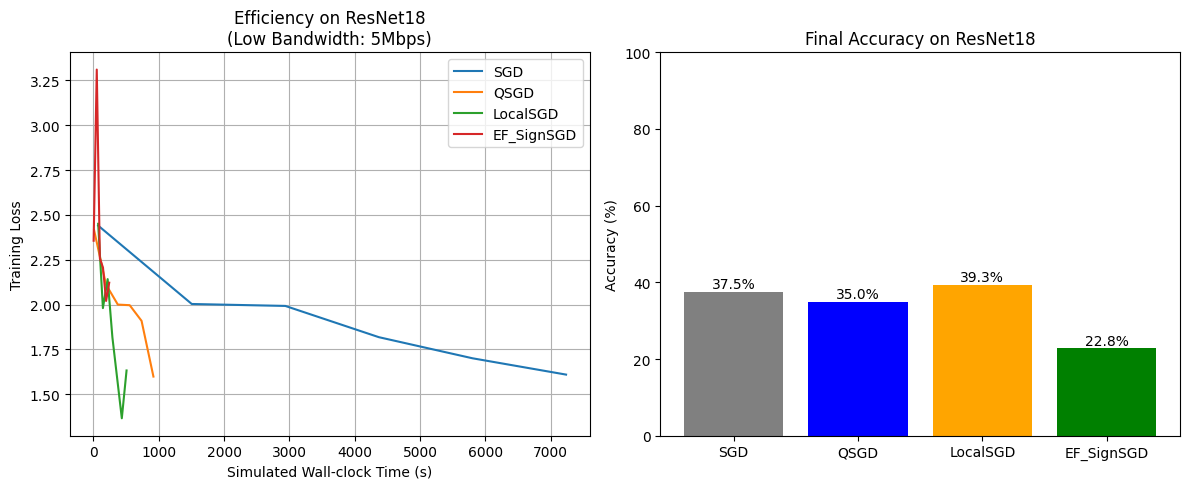

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import copy

# ==========================================
# تنظیمات پایه و سخت‌افزار
# ==========================================
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

# ==========================================
# 1. تعریف مدل‌های استاندارد (ResNet & VGG) برای CIFAR-10
# ==========================================
# نکته: مدل‌های torchvision برای ImageNet (224x224) طراحی شده‌اند.
# برای CIFAR-10 (32x32) باید لایه اول و Pooling را تغییر دهیم تا اطلاعات از بین نرود.

def get_model(model_name):
    if model_name == 'ResNet18':
        # ارجاع: He et al., 2016
        model = torchvision.models.resnet18(pretrained=False)
        # تغییر لایه اول برای تصاویر کوچک 32x32
        model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        model.maxpool = nn.Identity() # حذف MaxPool اولیه
        model.fc = nn.Linear(512, 10) # تغییر خروجی به 10 کلاس
        print("Model: ResNet-18 (Modified for CIFAR-10) | Params: ~11M")

    elif model_name == 'VGG11':
        # ارجاع: Simonyan & Zisserman, 2014 (استفاده شده در مقاله Karimireddy)
        model = torchvision.models.vgg11_bn(pretrained=False)
        # تغییر Classifier نهایی برای 10 کلاس
        # VGG پارامترهای بسیار زیادی در لایه‌های Linear دارد -> عالی برای تست فشرده‌سازی
        model.classifier[6] = nn.Linear(4096, 10)
        print("Model: VGG-11 (Modified for CIFAR-10) | Params: ~132M")

    else:
        raise ValueError("Model not supported")

    return model.to(device)

# ==========================================
# 2. آماده‌سازی داده‌ها
# ==========================================
print("Preparing Data...")
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # Data Augmentation (استاندارد مقالات)
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# برای تست سریع‌تر، فقط از 20% داده‌ها استفاده می‌کنیم (در پروژه نهایی کل دیتا را بگذارید)
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
subset_indices = list(range(0, 5000)) # 5000 عکس برای سرعت
trainset = torch.utils.data.Subset(full_trainset, subset_indices)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0)

# ==========================================
# 3. توابع فشرده‌سازی و شبیه‌سازی شبکه
# ==========================================
def quantize_qsgd(tensor, num_bits=4):
    """QSGD: Unbiased Quantization (Alistarh et al.)"""
    levels = 2 ** num_bits - 1
    norm = tensor.norm()
    if norm == 0: return tensor
    abs_tensor = tensor.abs()
    level_float = (abs_tensor / norm) * levels
    # Stochastic Rounding
    quantized = level_float.floor() + (torch.rand_like(tensor) < (level_float - level_float.floor())).float()
    return quantized * (norm / levels) * tensor.sign()

def sign_compress(tensor):
    """SignSGD: Biased 1-bit Compression (Bernstein/Karimireddy)"""
    return torch.sign(tensor)

def calc_simulated_time(size_bytes, bandwidth_mbps, latency_sec):
    """Network Model: Time = Latency + (Size / Bandwidth)"""
    transfer_time = (size_bytes * 8) / (bandwidth_mbps * 1e6)
    return latency_sec + transfer_time

# ==========================================
# 4. حلقه آموزش (Training Loop)
# ==========================================
def run_training(method, model_name, net_params, epochs=5):
    # تنظیمات هایپرپارامتر طبق مقاله Karimireddy Appendix A
    lr = 0.01 if model_name == 'ResNet18' else 0.05

    model = get_model(model_name)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

    # بافر خطا برای EF (Error Feedback)
    error_buffer = {n: torch.zeros_like(p) for n, p in model.named_parameters()}

    metrics = {'time': [0], 'loss': [], 'accuracy': []}
    sim_time = 0.0

    # تنظیم گام‌های لوکال برای Local SGD (مقاله Stich)
    local_steps = 16 if method == 'LocalSGD' else 1

    print(f"--- Starting {method} on {model_name} ---")

    global_step = 0
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (inputs, targets) in enumerate(trainloader):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()

            # Forward
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            # --- شبیه‌سازی Distributed ---
            comm_overhead = 0.0
            total_bytes = 0

            # فقط در زمان همگام‌سازی (Sync)
            if global_step % local_steps == 0:
                with torch.no_grad():
                    for name, p in model.named_parameters():
                        if p.grad is None: continue
                        grad = p.grad

                        # 1. Error Feedback (Karimireddy)
                        if 'EF' in method:
                            grad = grad + error_buffer[name]

                        # 2. Compression
                        if method == 'QSGD':
                            # 4-bit = 0.5 byte
                            p.grad = quantize_qsgd(grad, num_bits=4)
                            total_bytes += p.numel() * 0.5

                        elif 'SignSGD' in method:
                            # 1-bit compression
                            compressed = sign_compress(grad)
                            if 'EF' in method:
                                error_buffer[name] = grad - compressed # Update Error
                            p.grad = compressed
                            total_bytes += p.numel() / 8.0 # 1 bit = 1/8 byte

                        else: # SGD or LocalSGD (32-bit float)
                            total_bytes += p.numel() * 4

                # محاسبه زمان شبکه
                if total_bytes > 0:
                    comm_overhead = calc_simulated_time(total_bytes, net_params['bw'], net_params['lat'])

            # زمان محاسبات (تخمینی) + زمان شبکه
            # ResNet محاسبات بیشتری نسبت به مدل ساده دارد
            compute_time = 0.05 if model_name == 'ResNet18' else 0.04
            sim_time += compute_time + comm_overhead

            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            global_step += 1

            if batch_idx % 20 == 0:
                metrics['loss'].append(loss.item())
                metrics['time'].append(sim_time)

        acc = 100. * correct / total
        metrics['accuracy'].append(acc)
        print(f"Epoch {epoch+1} | Acc: {acc:.2f}% | Time: {sim_time:.1f}s")

    return metrics

# ==========================================
# 5. اجرای مقایسه‌ای
# ==========================================

# سناریو: اینترنت خانگی ضعیف (پهنای باند کم)
# اینجا VGG باید فاجعه باشد مگر اینکه فشرده شود!
scenario = {
    "bw": 5,      # 5 Mbps (Low Bandwidth)
    "lat": 0.1    # 100ms
}

# انتخاب مدل: اینجا می‌توانید 'ResNet18' یا 'VGG11' را انتخاب کنید
target_model = 'ResNet18'

methods_to_test = ['SGD', 'QSGD', 'LocalSGD', 'EF_SignSGD']
history = {}

print(f"Running comparison on {target_model} with Low Bandwidth Scenario...")

for method in methods_to_test:
    history[method] = run_training(method, target_model, scenario, epochs=3)

# ==========================================
# 6. رسم نمودار
# ==========================================
plt.figure(figsize=(12, 5))

# نمودار 1: دقت در برابر زمان
plt.subplot(1, 2, 1)
for method in methods_to_test:
    # همگام‌سازی محور x و y
    times = history[method]['time'][1:] # حذف 0 اولیه
    losses = history[method]['loss']
    min_len = min(len(times), len(losses))
    plt.plot(times[:min_len], losses[:min_len], label=method)

plt.title(f"Efficiency on {target_model}\n(Low Bandwidth: 5Mbps)")
plt.xlabel("Simulated Wall-clock Time (s)")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)

# نمودار 2: دقت نهایی
plt.subplot(1, 2, 2)
final_accs = [history[m]['accuracy'][-1] for m in methods_to_test]
plt.bar(methods_to_test, final_accs, color=['gray', 'blue', 'orange', 'green'])
plt.title(f"Final Accuracy on {target_model}")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
for i, v in enumerate(final_accs):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()
